In [4]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
TRAIN_DIR   = Path('../data/processed_garbage/train')
IMAGE_SIZE  = (224, 224)
OUTPUT_PATH = 'enhancement_comparison.png'
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [6]:
def enhance_image(bgr_img):
    lab = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    enhanced = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    enhanced = cv2.morphologyEx(enhanced, cv2.MORPH_OPEN, kernel)
    return enhanced

In [7]:
class_names = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f"{len(class_names)} classes: {class_names}")

samples = []
for cls in class_names:
    cls_dir = TRAIN_DIR / cls
    imgs = [p for p in cls_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    chosen = random.choice(imgs)
    bgr = cv2.imread(str(chosen))
    bgr = cv2.resize(bgr, IMAGE_SIZE)
    samples.append((cls, bgr))

print(f"Loaded {len(samples)} samples.")

12 classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Loaded 12 samples.


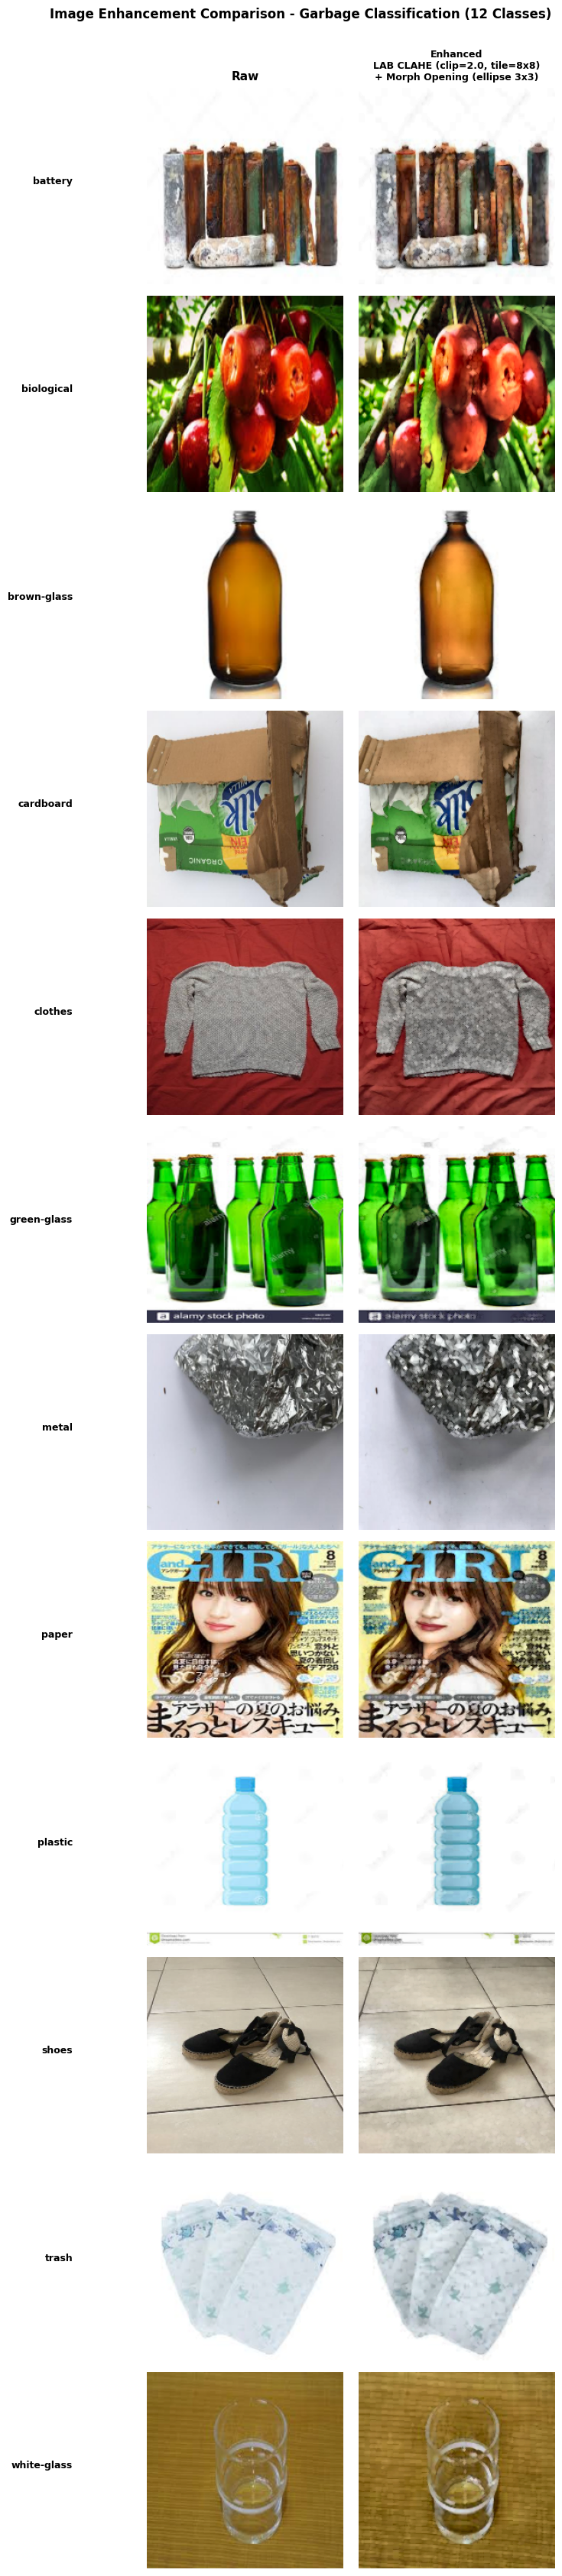

Saved -> enhancement_comparison.png


In [8]:
ENHANCEMENT_LABEL = "LAB CLAHE (clip=2.0, tile=8x8)\n+ Morph Opening (ellipse 3x3)"

n_classes = len(samples)
fig, axes = plt.subplots(n_classes, 2, figsize=(8, n_classes * 2.8))

axes[0, 0].set_title('Raw', fontsize=11, fontweight='bold', pad=8)
axes[0, 1].set_title(f'Enhanced\n{ENHANCEMENT_LABEL}', fontsize=9, fontweight='bold', pad=8)

for row, (cls_name, bgr_raw) in enumerate(samples):
    bgr_enhanced = enhance_image(bgr_raw)
    rgb_raw      = cv2.cvtColor(bgr_raw,      cv2.COLOR_BGR2RGB)
    rgb_enhanced = cv2.cvtColor(bgr_enhanced, cv2.COLOR_BGR2RGB)

    axes[row, 0].imshow(rgb_raw)
    axes[row, 0].set_yticks([])
    axes[row, 0].set_xticks([])
    axes[row, 0].set_ylabel(cls_name, fontsize=9, rotation=0,
                             labelpad=70, va='center', ha='right', fontweight='bold')
    axes[row, 0].yaxis.set_label_position('left')
    for spine in axes[row, 0].spines.values():
        spine.set_visible(False)

    axes[row, 1].imshow(rgb_enhanced)
    axes[row, 1].axis('off')

plt.suptitle('Image Enhancement Comparison - Garbage Classification (12 Classes)',
             fontsize=12, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {OUTPUT_PATH}')